In [1]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

In [2]:
# Loading the cleaned files
current_path = Path.cwd()

if current_path.name == 'notebooks':
    project_path = current_path.parent
else:
    project_path = current_path

data_path = project_path / 'data' / 'processed'

if not data_path.exists():
    project_path = current_path.parent
    data_path = project_path / 'data' / 'processed'

customers = pd.read_csv(data_path / 'customers.csv', parse_dates=['signup_date'])

memberships = pd.read_csv(
    data_path / 'memberships.csv',
    parse_dates=[
        'membership_start_date',
        'renewal_date',
        'membership_end_date',
        'cancellation_date'
    ]
)

orders = pd.read_csv(data_path / 'orders.csv', parse_dates=['order_date'])
prime_video = pd.read_csv(data_path / 'prime_video_activity.csv', parse_dates=['activity_date'])
payments = pd.read_csv(data_path / 'payments.csv', parse_dates=['payment_date'])
support = pd.read_csv(data_path / 'support_interactions.csv', parse_dates=['ticket_date'])

print('Customers:', len(customers))
print('Memberships:', len(memberships))
print('Orders:', len(orders))
print('Prime Video activity:', len(prime_video))
print('Payments:', len(payments))
print('Support interactions:', len(support))

Customers: 50000
Memberships: 55000
Orders: 399976
Prime Video activity: 549970
Payments: 124984
Support interactions: 34990


In [3]:
# Preparing the latest membership for every customer
report_date = pd.Timestamp('2026-06-30')

memberships = memberships.sort_values(
    ['customer_id', 'membership_start_date', 'renewal_date', 'membership_id']
)

latest_membership = memberships.drop_duplicates('customer_id', keep='last').copy()

latest_membership['customer_group'] = np.select(
    [
        latest_membership['membership_status'].eq('Active'),
        latest_membership['membership_status'].isin(['Cancelled', 'Expired'])
    ],
    ['Retained', 'Churned'],
    default='Other'
)

latest_membership['churn_flag'] = (
    latest_membership['customer_group'].eq('Churned').astype(int)
)

tenure_end = latest_membership['membership_end_date'].fillna(report_date)
tenure_end = tenure_end.where(tenure_end <= report_date, report_date)

latest_membership['tenure_months'] = (
    (tenure_end - latest_membership['membership_start_date']).dt.days / 30.44
).clip(lower=0)

latest_membership['tenure_band'] = pd.cut(
    latest_membership['tenure_months'],
    bins=[-1, 3, 6, 12, 24, np.inf],
    labels=[
        '0-3 months',
        '4-6 months',
        '7-12 months',
        '13-24 months',
        'More than 24 months'
    ]
)

customer_status = latest_membership[
    [
        'customer_id',
        'customer_group',
        'churn_flag',
        'plan_type',
        'auto_renew_enabled',
        'tenure_band',
        'cancellation_reason'
    ]
].copy()

print('Retained means the latest membership is Active.')
print('Churned means the latest membership is Cancelled or Expired.')
print('Paused and Payment Pending customers are kept as Other.')

Retained means the latest membership is Active.
Churned means the latest membership is Cancelled or Expired.
Paused and Payment Pending customers are kept as Other.


CUSTOMER ANALYSIS

Customers by country


,customers
country,
India,16389
United States,11863
United Kingdom,4536
Germany,3712
Canada,3466
Japan,2989
Australia,2501
Brazil,2473
Mexico,2071


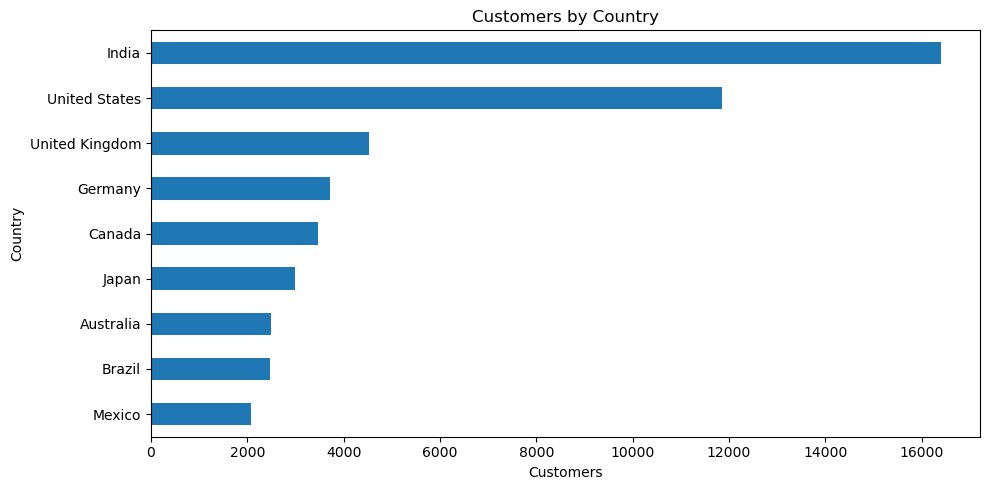


Customers by acquisition channel


,customers
acquisition_channel,
Amazon Shopping,12658
Organic Search,12270
Referral,6861
Paid Advertising,6081
Device Promotion,4999
Social Media,4996
Student Promotion,1935
Unknown,200


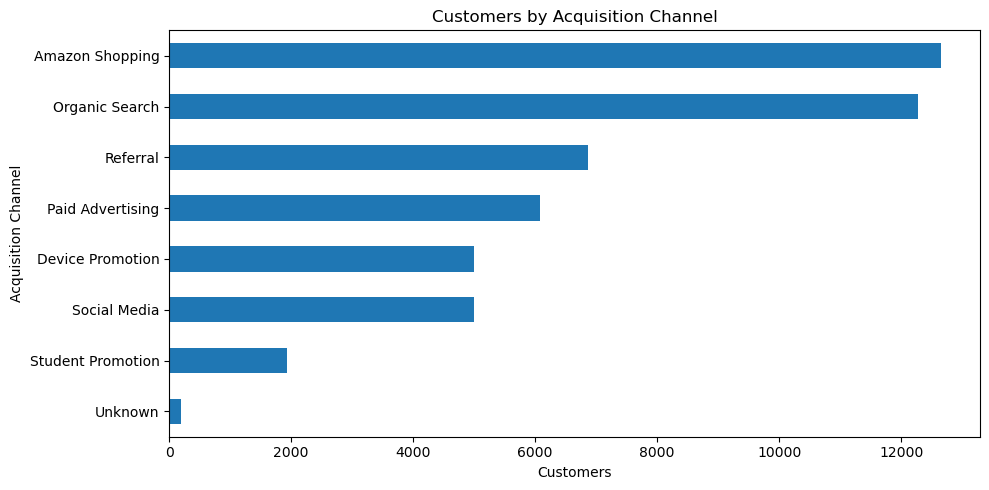


Customers by age group


,customers
age_group,
18-24,9599
25-34,14445
35-44,11530
45-54,7896
55-64,4557
65+,1973


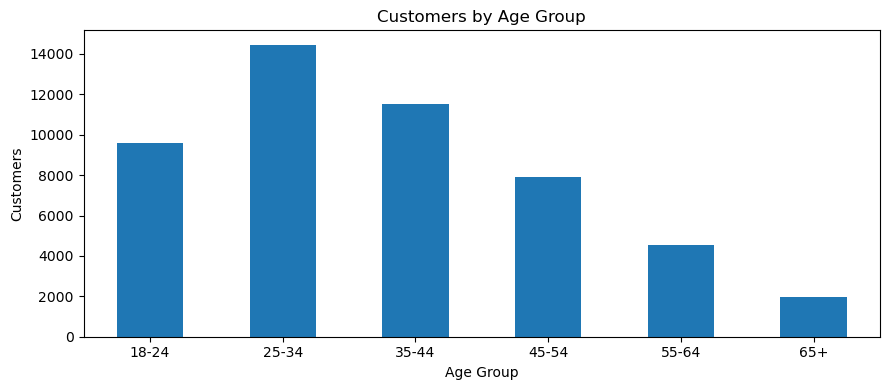


Customers by primary device


,customers
primary_device,
Mobile,19256
Fire TV,9483
Smart TV,7788
Desktop,6666
Tablet,4410
Game Console,2247
Unknown,150


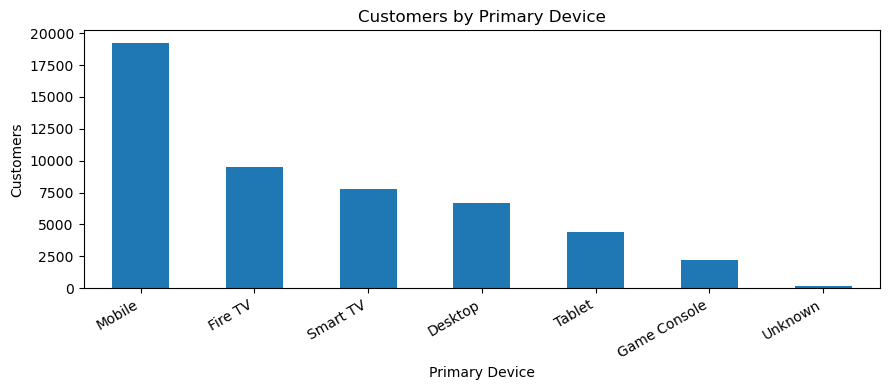


Customer signups by month


,new_customers
signup_date,
2025-07-01,2425
2025-08-01,2115
2025-09-01,1962
2025-10-01,2574
2025-11-01,2586
2025-12-01,2154
2026-01-01,2789
2026-02-01,2193
2026-03-01,2383


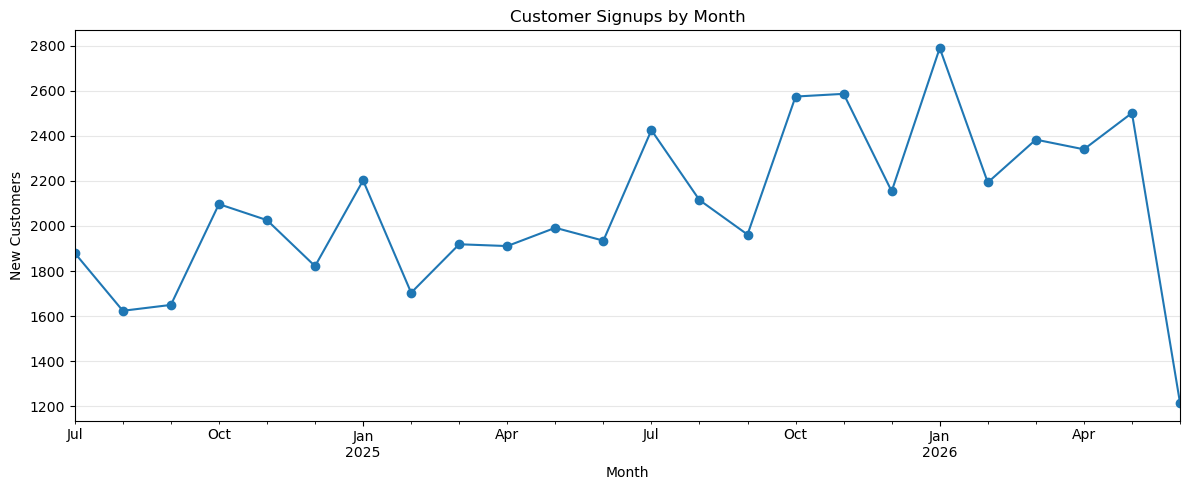

In [4]:
# Customer analysis
print('CUSTOMER ANALYSIS')

country_counts = customers['country'].value_counts()
print('\nCustomers by country')
display(country_counts.to_frame('customers'))

plt.figure(figsize=(10, 5))
country_counts.sort_values().plot(kind='barh')
plt.title('Customers by Country')
plt.xlabel('Customers')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

channel_counts = customers['acquisition_channel'].value_counts()
print('\nCustomers by acquisition channel')
display(channel_counts.to_frame('customers'))

plt.figure(figsize=(10, 5))
channel_counts.sort_values().plot(kind='barh')
plt.title('Customers by Acquisition Channel')
plt.xlabel('Customers')
plt.ylabel('Acquisition Channel')
plt.tight_layout()
plt.show()

age_order = ['18-24', '25-34', '35-44', '45-54', '55-64', '65+']
age_counts = customers['age_group'].value_counts().reindex(age_order, fill_value=0)
print('\nCustomers by age group')
display(age_counts.to_frame('customers'))

plt.figure(figsize=(9, 4))
age_counts.plot(kind='bar')
plt.title('Customers by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

device_counts = customers['primary_device'].value_counts()
print('\nCustomers by primary device')
display(device_counts.to_frame('customers'))

plt.figure(figsize=(9, 4))
device_counts.plot(kind='bar')
plt.title('Customers by Primary Device')
plt.xlabel('Primary Device')
plt.ylabel('Customers')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

signup_month = customers.groupby(
    customers['signup_date'].dt.to_period('M')
)['customer_id'].nunique()

signup_month.index = signup_month.index.to_timestamp()

print('\nCustomer signups by month')
display(signup_month.tail(12).to_frame('new_customers'))

plt.figure(figsize=(12, 5))
signup_month.plot(marker='o')
plt.title('Customer Signups by Month')
plt.xlabel('Month')
plt.ylabel('New Customers')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

MEMBERSHIP ANALYSIS

Active versus churned members


,customers
customer_group,
Retained,35301
Churned,10619


Overall churn rate: 23.12%


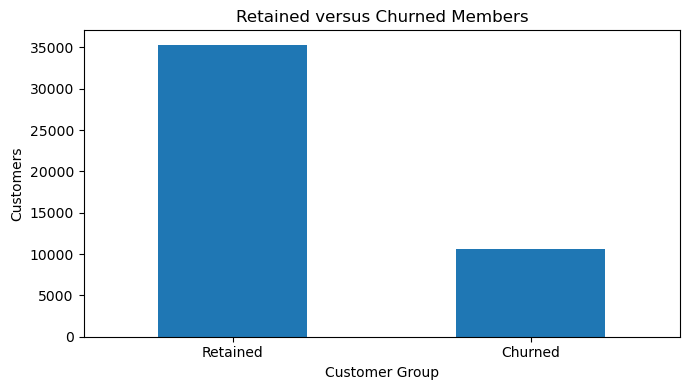


Membership plan distribution


,customers
plan_type,
Prime Standard,45288
Prime Student,4403
Prime Trial,309


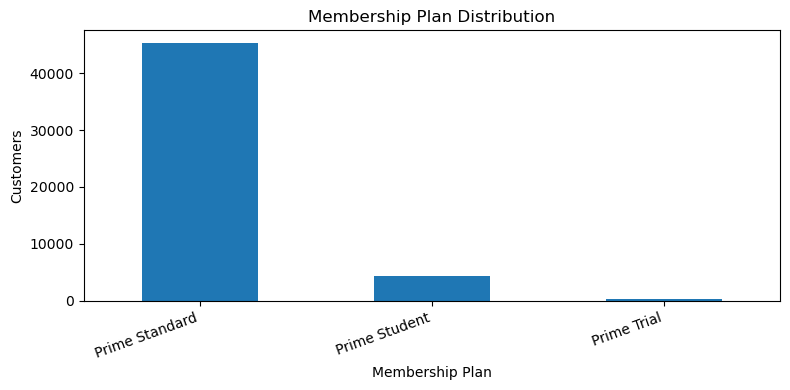


Churn rate by membership plan


,churn_rate_percent
plan_type,
Prime Standard,23.28
Prime Student,23.11
Prime Trial,0.00


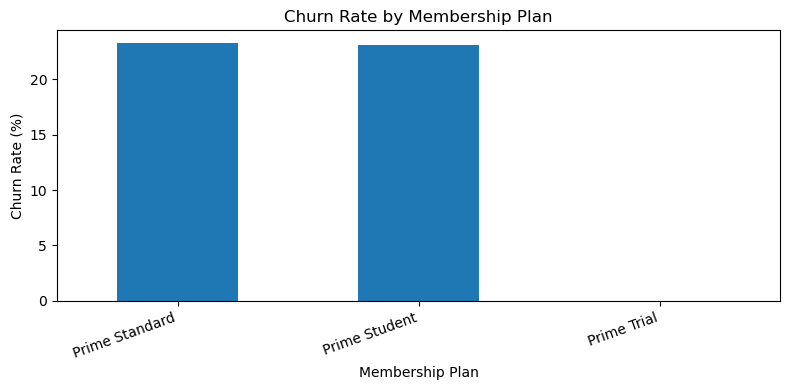


Churn rate by membership tenure


,churn_rate_percent
tenure_band,
0-3 months,21.51
4-6 months,28.25
7-12 months,25.95
13-24 months,17.23
More than 24 months,NaN


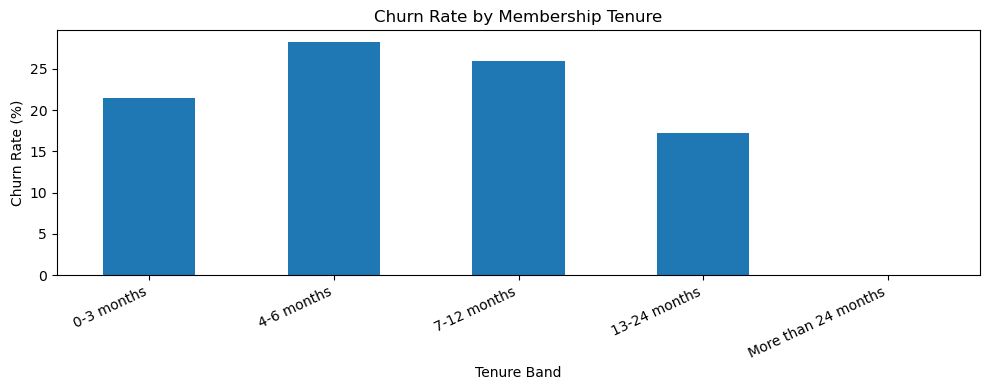


Churn rate by auto-renewal


,churn_rate_percent
auto_renew_group,
Disabled,54.67
Enabled,6.21
Unknown,16.48


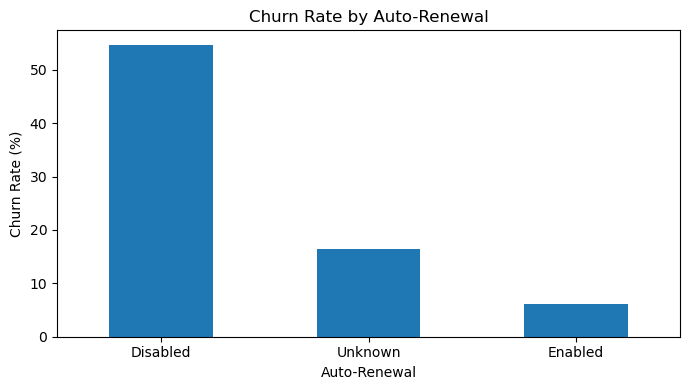


Cancellation reasons


,customers
cancellation_reason,
Too Expensive,2566
Content Dissatisfaction,1794
Low Usage,1552
Delivery Issues,1302
Switched Service,1044
Payment Failure,1038
Unknown,956
Temporary Membership,367


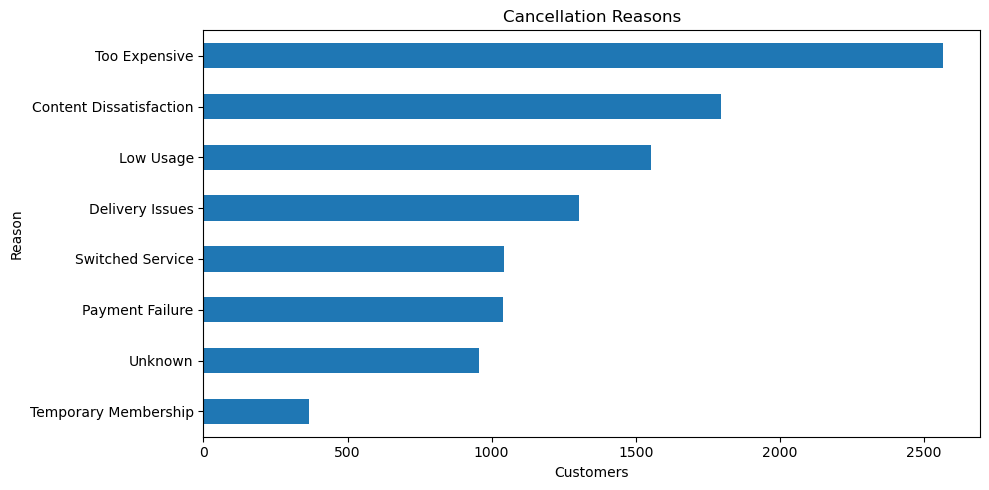

In [5]:
# Membership analysis
print('MEMBERSHIP ANALYSIS')

eligible_members = latest_membership[
    latest_membership['customer_group'].isin(['Retained', 'Churned'])
].copy()

group_counts = eligible_members['customer_group'].value_counts()
overall_churn_rate = eligible_members['churn_flag'].mean() * 100

print('\nActive versus churned members')
display(group_counts.to_frame('customers'))
print(f'Overall churn rate: {overall_churn_rate:.2f}%')

plt.figure(figsize=(7, 4))
group_counts.plot(kind='bar')
plt.title('Retained versus Churned Members')
plt.xlabel('Customer Group')
plt.ylabel('Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

plan_distribution = latest_membership['plan_type'].value_counts()
print('\nMembership plan distribution')
display(plan_distribution.to_frame('customers'))

plt.figure(figsize=(8, 4))
plan_distribution.plot(kind='bar')
plt.title('Membership Plan Distribution')
plt.xlabel('Membership Plan')
plt.ylabel('Customers')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

churn_by_plan = eligible_members.groupby('plan_type')['churn_flag'].mean() * 100
churn_by_plan = churn_by_plan.sort_values(ascending=False)
print('\nChurn rate by membership plan')
display(churn_by_plan.to_frame('churn_rate_percent'))

plt.figure(figsize=(8, 4))
churn_by_plan.plot(kind='bar')
plt.title('Churn Rate by Membership Plan')
plt.xlabel('Membership Plan')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

churn_by_tenure = eligible_members.groupby(
    'tenure_band', observed=False
)['churn_flag'].mean() * 100

print('\nChurn rate by membership tenure')
display(churn_by_tenure.to_frame('churn_rate_percent'))

plt.figure(figsize=(10, 4))
churn_by_tenure.plot(kind='bar')
plt.title('Churn Rate by Membership Tenure')
plt.xlabel('Tenure Band')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

auto_renew_data = eligible_members.copy()
auto_renew_data['auto_renew_group'] = auto_renew_data['auto_renew_enabled'].map(
    {True: 'Enabled', False: 'Disabled'}
).fillna('Unknown')

churn_by_auto_renew = auto_renew_data.groupby(
    'auto_renew_group'
)['churn_flag'].mean() * 100

print('\nChurn rate by auto-renewal')
display(churn_by_auto_renew.to_frame('churn_rate_percent'))

plt.figure(figsize=(7, 4))
churn_by_auto_renew.sort_values(ascending=False).plot(kind='bar')
plt.title('Churn Rate by Auto-Renewal')
plt.xlabel('Auto-Renewal')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

cancellation_reasons = latest_membership.loc[
    latest_membership['customer_group'].eq('Churned'),
    'cancellation_reason'
].value_counts()

print('\nCancellation reasons')
display(cancellation_reasons.to_frame('customers'))

plt.figure(figsize=(10, 5))
cancellation_reasons.sort_values().plot(kind='barh')
plt.title('Cancellation Reasons')
plt.xlabel('Customers')
plt.ylabel('Reason')
plt.tight_layout()
plt.show()

SHOPPING ANALYSIS
Orders per customer: 7.84
Average order value: 40.80
Late-delivery rate: 5.75%
Return rate: 7.09%

Most purchased categories


,orders
product_category,
Home & Kitchen,54733
Electronics,51179
Grocery,50509
Fashion,46722
Health & Personal Care,31209
Beauty,30992
Books,27317
Toys & Games,23568
Sports & Outdoors,19680


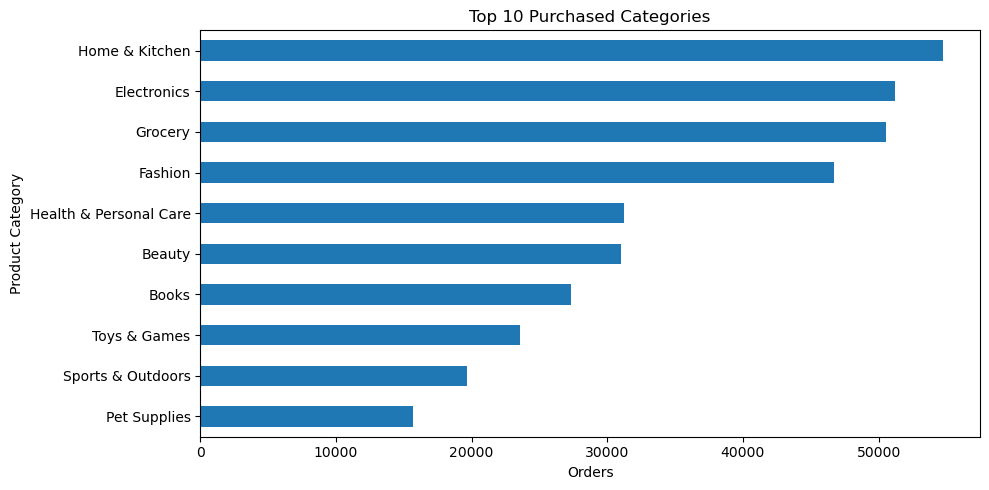


Shopping activity of retained versus churned customers


,order_count,total_order_value,average_order_value
customer_group,,,
Churned,6.05,246.11,36.59
Retained,8.31,339.18,36.81


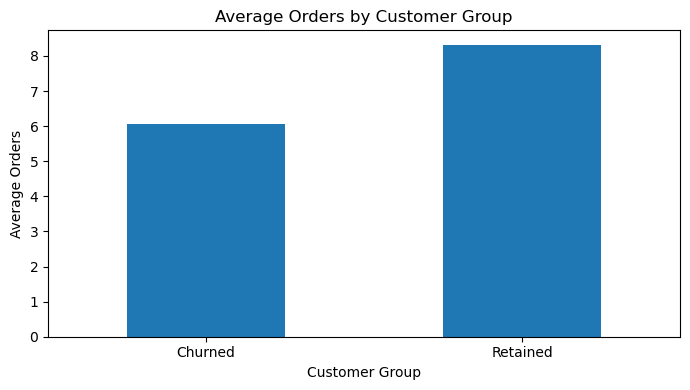

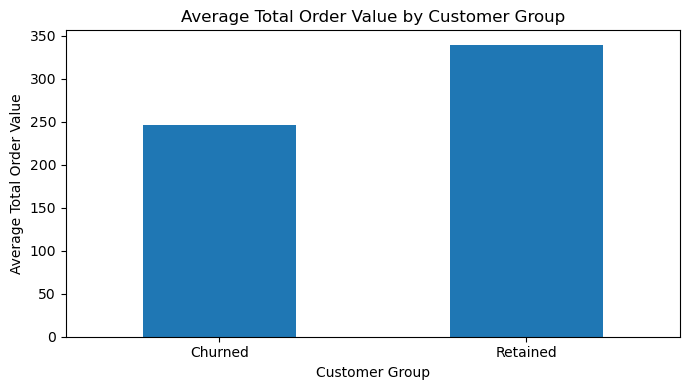

In [6]:
# Shopping analysis
print('SHOPPING ANALYSIS')

valid_orders = orders[orders['order_status'].ne('Cancelled')].copy()

orders_per_customer = len(valid_orders) / customers['customer_id'].nunique()
average_order_value = valid_orders['order_value'].mean()

delivered_orders = orders[orders['order_status'].eq('Delivered')]
late_delivery_rate = delivered_orders['delivered_late_flag'].mean() * 100

return_eligible_orders = orders[
    orders['order_status'].isin(['Delivered', 'Returned'])
]
return_rate = return_eligible_orders['returned_flag'].mean() * 100

print(f'Orders per customer: {orders_per_customer:.2f}')
print(f'Average order value: {average_order_value:,.2f}')
print(f'Late-delivery rate: {late_delivery_rate:.2f}%')
print(f'Return rate: {return_rate:.2f}%')

category_orders = valid_orders['product_category'].value_counts().head(10)
print('\nMost purchased categories')
display(category_orders.to_frame('orders'))

plt.figure(figsize=(10, 5))
category_orders.sort_values().plot(kind='barh')
plt.title('Top 10 Purchased Categories')
plt.xlabel('Orders')
plt.ylabel('Product Category')
plt.tight_layout()
plt.show()

customer_orders = valid_orders.groupby('customer_id').agg(
    order_count=('order_id', 'nunique'),
    total_order_value=('order_value', 'sum'),
    average_order_value=('order_value', 'mean')
).reset_index()

shopping_comparison = customer_status[
    ['customer_id', 'customer_group']
].merge(customer_orders, on='customer_id', how='left')

shopping_comparison[
    ['order_count', 'total_order_value', 'average_order_value']
] = shopping_comparison[
    ['order_count', 'total_order_value', 'average_order_value']
].fillna(0)

shopping_summary = shopping_comparison[
    shopping_comparison['customer_group'].isin(['Retained', 'Churned'])
].groupby('customer_group')[
    ['order_count', 'total_order_value', 'average_order_value']
].mean()

print('\nShopping activity of retained versus churned customers')
display(shopping_summary)

plt.figure(figsize=(7, 4))
shopping_summary['order_count'].plot(kind='bar')
plt.title('Average Orders by Customer Group')
plt.xlabel('Customer Group')
plt.ylabel('Average Orders')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
shopping_summary['total_order_value'].plot(kind='bar')
plt.title('Average Total Order Value by Customer Group')
plt.xlabel('Customer Group')
plt.ylabel('Average Total Order Value')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

PRIME VIDEO ANALYSIS
Total watch hours: 961,806.81
Sessions per customer: 21.13

Content type distribution


,activity_records
content_type,
Movie,203356
TV Series,197976
Live Sports,44312
Documentary,38432
Kids,38316
Channel,27458
Live Channel,120


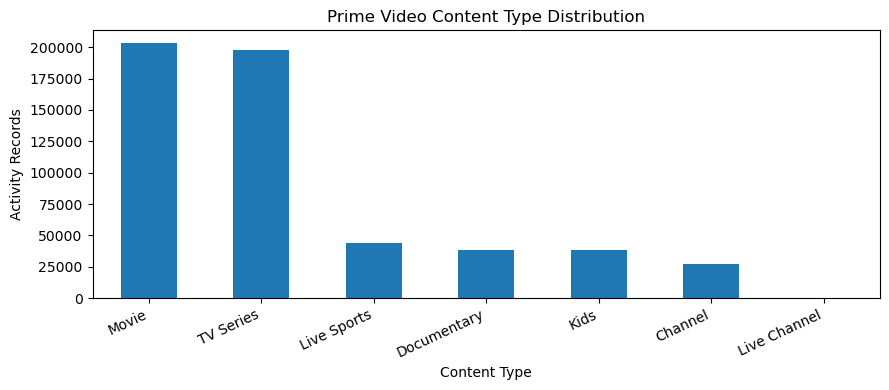


Prime Video device distribution


,activity_records
device_type,
Mobile,198318
Fire TV,112053
Smart TV,95116
Desktop,68150
Tablet,48349
Game Console,26884
Unknown,1100


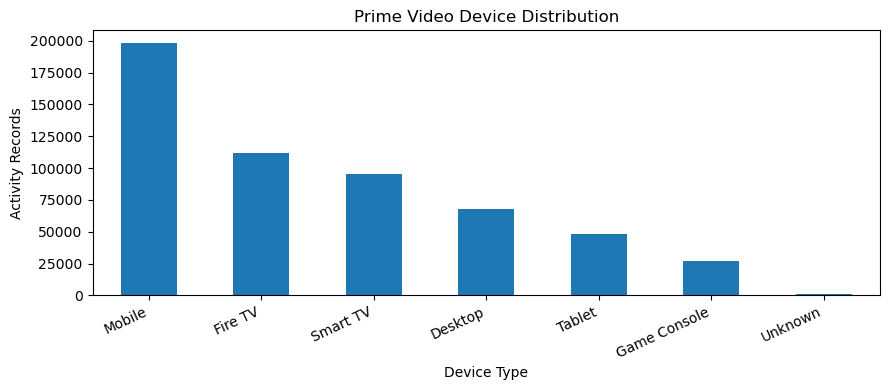


Prime Video engagement of retained versus churned customers


,watch_hours,video_sessions,titles_watched
customer_group,,,
Churned,15.14,16.48,21.80
Retained,20.25,22.29,29.63


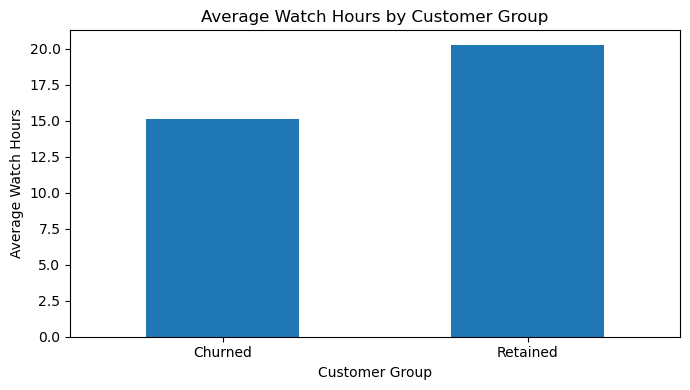

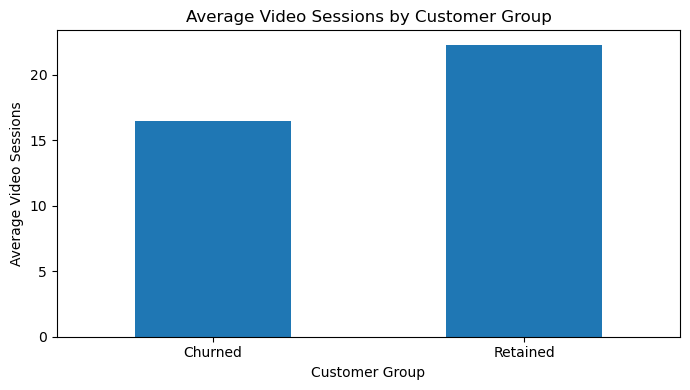

In [7]:
# Prime Video analysis
print('PRIME VIDEO ANALYSIS')

total_watch_hours = prime_video['watch_minutes'].sum() / 60
sessions_per_customer = (
    prime_video['sessions_count'].sum() / customers['customer_id'].nunique()
)

print(f'Total watch hours: {total_watch_hours:,.2f}')
print(f'Sessions per customer: {sessions_per_customer:.2f}')

content_distribution = prime_video['content_type'].value_counts()
print('\nContent type distribution')
display(content_distribution.to_frame('activity_records'))

plt.figure(figsize=(9, 4))
content_distribution.plot(kind='bar')
plt.title('Prime Video Content Type Distribution')
plt.xlabel('Content Type')
plt.ylabel('Activity Records')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

video_device_distribution = prime_video['device_type'].value_counts()
print('\nPrime Video device distribution')
display(video_device_distribution.to_frame('activity_records'))

plt.figure(figsize=(9, 4))
video_device_distribution.plot(kind='bar')
plt.title('Prime Video Device Distribution')
plt.xlabel('Device Type')
plt.ylabel('Activity Records')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

customer_video = prime_video.groupby('customer_id').agg(
    watch_hours=('watch_minutes', lambda values: values.sum() / 60),
    video_sessions=('sessions_count', 'sum'),
    titles_watched=('titles_watched', 'sum')
).reset_index()

video_comparison = customer_status[
    ['customer_id', 'customer_group']
].merge(customer_video, on='customer_id', how='left')

video_comparison[
    ['watch_hours', 'video_sessions', 'titles_watched']
] = video_comparison[
    ['watch_hours', 'video_sessions', 'titles_watched']
].fillna(0)

video_summary = video_comparison[
    video_comparison['customer_group'].isin(['Retained', 'Churned'])
].groupby('customer_group')[
    ['watch_hours', 'video_sessions', 'titles_watched']
].mean()

print('\nPrime Video engagement of retained versus churned customers')
display(video_summary)

plt.figure(figsize=(7, 4))
video_summary['watch_hours'].plot(kind='bar')
plt.title('Average Watch Hours by Customer Group')
plt.xlabel('Customer Group')
plt.ylabel('Average Watch Hours')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
video_summary['video_sessions'].plot(kind='bar')
plt.title('Average Video Sessions by Customer Group')
plt.xlabel('Customer Group')
plt.ylabel('Average Video Sessions')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

PAYMENT AND SUPPORT ANALYSIS
Payment failure rate: 5.48%
Average payment retries: 0.026

Payment retry distribution


,payments
retry_count,
0,122150
1,2447
2,387


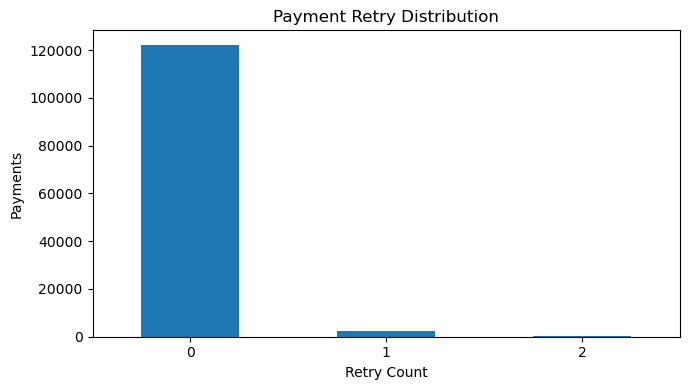

Support tickets per customer: 0.70
Average resolution time: 12.08 hours
Average satisfaction score: 3.55 out of 5

Support-ticket frequency


,customers
0 tickets,26791
1 ticket,15008
2 tickets,5653
3+ tickets,2548


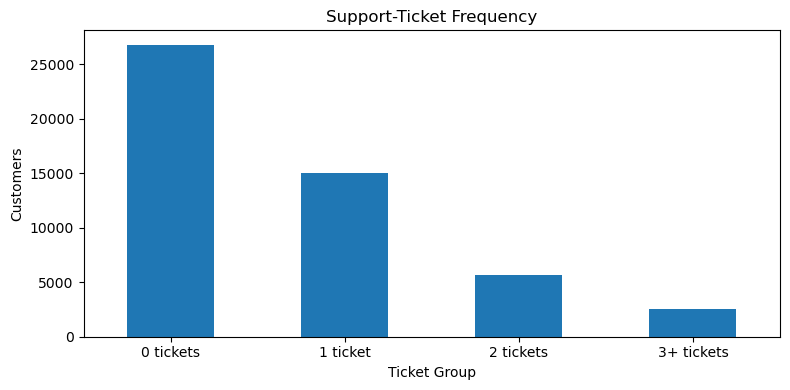


Churn rate among customers with complaints


,churn_rate_percent
has_complaint,
No Complaint,15.61
Has Complaint,31.64


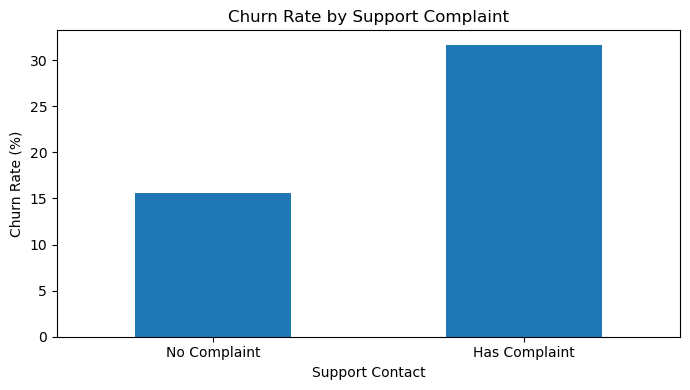


Churn rate by payment failure


,churn_rate_percent
has_payment_failure,
No Payment Failure,22.23
Has Payment Failure,30.18


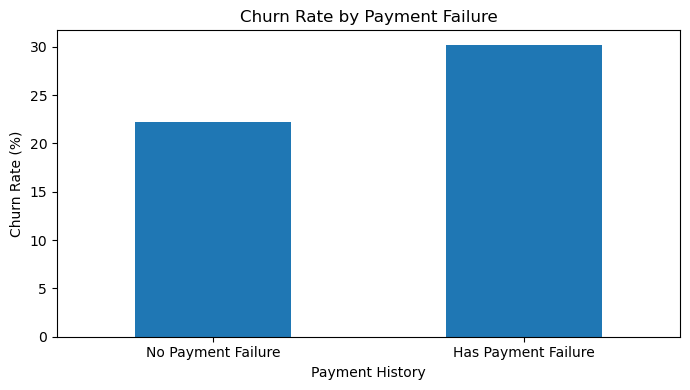


Support experience of retained versus churned customers


,ticket_count,average_satisfaction
customer_group,,
Churned,1.69,3.33
Retained,1.44,3.67


In [8]:
# Payment and support analysis
print('PAYMENT AND SUPPORT ANALYSIS')

eligible_payments = payments[payments['payment_status'].ne('Pending')]
payment_failure_rate = (
    eligible_payments['payment_status'].eq('Failed').mean() * 100
)
average_retry_count = payments['retry_count'].mean()

print(f'Payment failure rate: {payment_failure_rate:.2f}%')
print(f'Average payment retries: {average_retry_count:.3f}')

retry_distribution = payments['retry_count'].value_counts().sort_index()
print('\nPayment retry distribution')
display(retry_distribution.to_frame('payments'))

plt.figure(figsize=(7, 4))
retry_distribution.plot(kind='bar')
plt.title('Payment Retry Distribution')
plt.xlabel('Retry Count')
plt.ylabel('Payments')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

support_tickets_per_customer = (
    support['ticket_id'].nunique() / customers['customer_id'].nunique()
)
average_resolution_time = support.loc[
    support['resolved_flag'], 'resolution_hours'
].mean()
average_satisfaction = support['satisfaction_score'].mean()

print(f'Support tickets per customer: {support_tickets_per_customer:.2f}')
print(f'Average resolution time: {average_resolution_time:.2f} hours')
print(f'Average satisfaction score: {average_satisfaction:.2f} out of 5')

ticket_count = support.groupby('customer_id')['ticket_id'].nunique()

ticket_frequency = pd.Series({
    '0 tickets': customers['customer_id'].nunique() - ticket_count.size,
    '1 ticket': ticket_count.eq(1).sum(),
    '2 tickets': ticket_count.eq(2).sum(),
    '3+ tickets': ticket_count.ge(3).sum()
})

print('\nSupport-ticket frequency')
display(ticket_frequency.to_frame('customers'))

plt.figure(figsize=(8, 4))
ticket_frequency.plot(kind='bar')
plt.title('Support-Ticket Frequency')
plt.xlabel('Ticket Group')
plt.ylabel('Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

complaint_customers = set(support['customer_id'])
complaint_churn = customer_status[
    ['customer_id', 'customer_group', 'churn_flag']
].copy()
complaint_churn['has_complaint'] = complaint_churn['customer_id'].isin(
    complaint_customers
)

complaint_churn = complaint_churn[
    complaint_churn['customer_group'].isin(['Retained', 'Churned'])
]

complaint_churn_rate = complaint_churn.groupby(
    'has_complaint'
)['churn_flag'].mean() * 100
complaint_churn_rate.index = complaint_churn_rate.index.map(
    {False: 'No Complaint', True: 'Has Complaint'}
)

print('\nChurn rate among customers with complaints')
display(complaint_churn_rate.to_frame('churn_rate_percent'))

plt.figure(figsize=(7, 4))
complaint_churn_rate.plot(kind='bar')
plt.title('Churn Rate by Support Complaint')
plt.xlabel('Support Contact')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

failed_payment_customers = set(
    payments.loc[payments['payment_status'].eq('Failed'), 'customer_id']
)

payment_churn = customer_status[
    ['customer_id', 'customer_group', 'churn_flag']
].copy()
payment_churn['has_payment_failure'] = payment_churn['customer_id'].isin(
    failed_payment_customers
)

payment_churn = payment_churn[
    payment_churn['customer_group'].isin(['Retained', 'Churned'])
]

payment_churn_rate = payment_churn.groupby(
    'has_payment_failure'
)['churn_flag'].mean() * 100
payment_churn_rate.index = payment_churn_rate.index.map(
    {False: 'No Payment Failure', True: 'Has Payment Failure'}
)

print('\nChurn rate by payment failure')
display(payment_churn_rate.to_frame('churn_rate_percent'))

plt.figure(figsize=(7, 4))
payment_churn_rate.plot(kind='bar')
plt.title('Churn Rate by Payment Failure')
plt.xlabel('Payment History')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

customer_support = support.groupby('customer_id').agg(
    ticket_count=('ticket_id', 'nunique'),
    average_satisfaction=('satisfaction_score', 'mean')
).reset_index()

support_comparison = customer_status[
    ['customer_id', 'customer_group']
].merge(customer_support, on='customer_id', how='left')

support_summary = support_comparison[
    support_comparison['customer_group'].isin(['Retained', 'Churned'])
].groupby('customer_group')[
    ['ticket_count', 'average_satisfaction']
].mean()

print('\nSupport experience of retained versus churned customers')
display(support_summary)

In [9]:
# Early findings
print('EARLY CHURN-DRIVER OBSERVATIONS')

highest_tenure_churn = churn_by_tenure.dropna().idxmax()
highest_tenure_rate = churn_by_tenure.dropna().max()

auto_disabled_rate = churn_by_auto_renew.get('Disabled', np.nan)
auto_enabled_rate = churn_by_auto_renew.get('Enabled', np.nan)

retained_orders = shopping_summary.loc['Retained', 'order_count']
churned_orders = shopping_summary.loc['Churned', 'order_count']

retained_watch = video_summary.loc['Retained', 'watch_hours']
churned_watch = video_summary.loc['Churned', 'watch_hours']

complaint_rate = complaint_churn_rate.get('Has Complaint', np.nan)
no_complaint_rate = complaint_churn_rate.get('No Complaint', np.nan)

failure_rate = payment_churn_rate.get('Has Payment Failure', np.nan)
no_failure_rate = payment_churn_rate.get('No Payment Failure', np.nan)

retained_satisfaction = support_summary.loc['Retained', 'average_satisfaction']
churned_satisfaction = support_summary.loc['Churned', 'average_satisfaction']

print(f'1. The overall churn rate is {overall_churn_rate:.2f}%.')
print(
    f'2. Auto-renewal disabled customers have {auto_disabled_rate:.2f}% churn, '
    f'compared with {auto_enabled_rate:.2f}% when enabled.'
)
print(
    f'3. The highest churn tenure group is {highest_tenure_churn} '
    f'at {highest_tenure_rate:.2f}%.'
)
print(
    f'4. Retained customers average {retained_orders:.2f} orders, '
    f'while churned customers average {churned_orders:.2f} orders.'
)
print(
    f'5. Retained customers average {retained_watch:.2f} watch hours, '
    f'while churned customers average {churned_watch:.2f} watch hours.'
)
print(
    f'6. Customers with support complaints have {complaint_rate:.2f}% churn, '
    f'compared with {no_complaint_rate:.2f}% without complaints.'
)
print(
    f'7. Customers with payment failures have {failure_rate:.2f}% churn, '
    f'compared with {no_failure_rate:.2f}% without failures.'
)
print(
    f'8. Average support satisfaction is {retained_satisfaction:.2f} for retained '
    f'customers and {churned_satisfaction:.2f} for churned customers.'
)
print('\nThese are early associations. They do not prove that one factor caused churn.')

EARLY CHURN-DRIVER OBSERVATIONS
1. The overall churn rate is 23.12%.
2. Auto-renewal disabled customers have 54.67% churn, compared with 6.21% when enabled.
3. The highest churn tenure group is 4-6 months at 28.25%.
4. Retained customers average 8.31 orders, while churned customers average 6.05 orders.
5. Retained customers average 20.25 watch hours, while churned customers average 15.14 watch hours.
6. Customers with support complaints have 31.64% churn, compared with 15.61% without complaints.
7. Customers with payment failures have 30.18% churn, compared with 22.23% without failures.
8. Average support satisfaction is 3.67 for retained customers and 3.33 for churned customers.

These are early associations. They do not prove that one factor caused churn.
